# TinyChirp LEAF-Time TensorFlow

In [11]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path

repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
from typing import TYPE_CHECKING


from building_tensorflow.utils import (
    SAMPLE_RATE,
    FRAME_LENGTH,
    FRAME_STEP,
    TARGET_FRAMES_TIME,
    TARGET_AUDIO_LEN_TIME,
    DATASET_ROOT,
    get_paths,
    configure_tf_runtime,
    set_global_seed,
    make_time_datasets,
    build_representative_batches,
    export_keras_model_to_int8_tflite,
    collect_test_clips_for_rs,
    write_audio_sample_rs,
)

if TYPE_CHECKING:
    import keras
else:
    from tensorflow import keras

configure_tf_runtime()
set_global_seed()

paths = get_paths("leaf_time_tf")
OUT_TFLITE = paths.out_tflite
OUT_AUDIO_RS = paths.out_audio_rs

print("Dataset root:", DATASET_ROOT)
print("Model output:", OUT_TFLITE)
print("Audio sample output:", OUT_AUDIO_RS)
print("Sample rate:", SAMPLE_RATE)
print("Frame length:", FRAME_LENGTH)
print("Frame step:", FRAME_STEP)
print("Target frames (time):", TARGET_FRAMES_TIME)
print("Target audio length (time):", TARGET_AUDIO_LEN_TIME)


Dataset root: /home/nathan/Documents/tiny-chirp-microflow/dataset
Model output: /home/nathan/Documents/tiny-chirp-microflow/models/leaf_time_tf.tflite
Audio sample output: /home/nathan/Documents/tiny-chirp-microflow/src/audio_sample.rs
Sample rate: 16000
Frame length: 1024
Frame step: 256
Target frames (time): 184
Target audio length (time): 47872


In [13]:
train_ds, val_ds, test_ds, label_names = make_time_datasets()
num_labels = len(label_names)
print("Classes:", label_names)
print("Num labels:", num_labels)


Found 11292 files belonging to 2 classes.
Found 1380 files belonging to 2 classes.
Found 1393 files belonging to 2 classes.
Classes: ['non_target' 'target']
Num labels: 2


In [14]:
import math
import numpy as np
import tensorflow as tf
import keras

class GaborConv1D(keras.layers.Layer):
    def __init__(self, num_filters, kernel_size, stride=1, **kwargs):
        super().__init__(**kwargs)
        self.num_filters = num_filters
        self.kernel_size = kernel_size
        self.stride = stride

        # We initialize frequencies more uniformly to ensure it catches high-pitch birds
        self.center_freqs = self.add_weight(shape=(1, 1, num_filters), initializer="random_uniform")
        self.bandwidths = self.add_weight(shape=(1, 1, num_filters), initializer="ones")

    def get_filters(self):
        limit = (self.kernel_size - 1) / 2.0
        t = tf.cast(tf.linspace(-limit, limit, self.kernel_size), tf.float32)
        t = tf.reshape(t, [-1, 1, 1]) 
        env = tf.exp(-0.5 * tf.square(t * self.bandwidths))
        cos_mod = tf.cos(2.0 * math.pi * self.center_freqs * t)
        sin_mod = tf.sin(2.0 * math.pi * self.center_freqs * t)
        return tf.concat([env * cos_mod, env * sin_mod], axis=-1)

    def call(self, inputs):
        conv = tf.nn.conv1d(inputs, self.get_filters(), stride=self.stride, padding='SAME')
        real, imag = tf.split(conv, 2, axis=-1)
        return tf.square(real) + tf.square(imag)


class GaussianPool1D(keras.layers.Layer):
    def __init__(self, num_filters, pool_size, stride, **kwargs):
        super().__init__(**kwargs)
        self.num_filters = num_filters
        self.pool_size = pool_size
        self.stride = stride
        self.bandwidths = self.add_weight(shape=(1, num_filters, 1), initializer=tf.constant_initializer(0.4))

    def get_filters(self):
        limit = (self.pool_size - 1) / 2.0
        t = tf.cast(tf.linspace(-limit, limit, self.pool_size), tf.float32)
        t = tf.reshape(t, [-1, 1, 1]) 
        gauss = tf.exp(-0.5 * tf.square(t * self.bandwidths))
        return gauss / tf.reduce_sum(gauss, axis=0, keepdims=True)

    def call(self, inputs):
        return tf.nn.depthwise_conv2d(
            tf.expand_dims(inputs, axis=1), 
            tf.expand_dims(self.get_filters(), axis=0), 
            strides=[1, 1, self.stride, 1], 
            padding='SAME'
        )[:, 0, :, :]


class LogCompression(keras.layers.Layer):
    """Instantly compresses audio without heavy loops. Perfect for CPU."""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.epsilon = 1e-6

    def call(self, inputs):
        return tf.math.log(inputs + self.epsilon)

In [15]:
NUM_FILTERS = 32
KERNEL_SIZE = 64
STRIDE = 32

def build_training_model(num_labels: int) -> keras.Model:
    inputs = keras.Input(shape=(TARGET_AUDIO_LEN_TIME, 1))

    x = GaborConv1D(num_filters=NUM_FILTERS, kernel_size=KERNEL_SIZE, stride=STRIDE, name="gabor_conv")(inputs)
    x = GaussianPool1D(num_filters=NUM_FILTERS, pool_size=KERNEL_SIZE, stride=1, name="gauss_pool")(x)
    x = LogCompression(name="log_compress")(x)
    
    x = keras.layers.GlobalAveragePooling1D()(x)
    x = keras.layers.Dense(64, activation='relu')(x)
    outputs = keras.layers.Dense(num_labels, activation=None, name="dense_logits")(x)
    
    return keras.Model(inputs, outputs, name="leaf_fast_bird_model")


num_labels = 2 
training_model = build_training_model(num_labels)

# Use XLA compilation to speed up training
training_model.compile(
    optimizer="adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
    jit_compile=True  # This forces TF to optimize the custom math loops
)

In [16]:
training_model.summary()

Model: "leaf_fast_bird_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 47872, 1)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gabor_conv (GaborConv1D)        │ (None, 1496, 32)       │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gauss_pool (GaussianPool1D)     │ (None, 1496, 32)       │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ log_compress (LogCompression)   │ (None, 1496, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_logits (Dense)            │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,338 (9.13 KB)

 Trainable params: 2,338 (9.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import wandb
from wandb.integration.keras import WandbMetricsLogger, WandbModelCheckpoint


wandb.init(
    # set the wandb project where this run will be logged
    name="leaf",
    project="tinychirp",

    # track hyperparameters and run metadata with wandb.config
    config={
        "num_filters": NUM_FILTERS,
        "kernel_size": KERNEL_SIZE,
        "stride": STRIDE,
    }
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',        
    patience=5,               
    restore_best_weights=True
)

history = training_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    validation_steps=50,
    callbacks=[early_stopping, WandbMetricsLogger(log_freq=5), WandbModelCheckpoint("models.keras")] 
)

Epoch 1/40
353/353 ━━━━━━━━━━━━━━━━━━━━ 24s 61ms/step - accuracy: 0.6741 - loss: 0.6326 - val_accuracy: 0.6703 - val_loss: 0.5808
Epoch 2/40
353/353 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.7843 - loss: 0.4624 - val_accuracy: 0.9014 - val_loss: 0.2901
Epoch 3/40
353/353 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - accuracy: 0.8858 - loss: 0.2871 - val_accuracy: 0.8717 - val_loss: 0.2788
Epoch 4/40
353/353 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - accuracy: 0.8889 - loss: 0.2544 - val_accuracy: 0.9181 - val_loss: 0.1855
Epoch 5/40
353/353 ━━━━━━━━━━━━━━━━━━━━ 23s 64ms/step - accuracy: 0.9019 - loss: 0.2251 - val_accuracy: 0.9341 - val_loss: 0.1528
Epoch 6/40
353/353 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.9129 - loss: 0.2047 - val_accuracy: 0.9493 - val_loss: 0.1335
Epoch 7/40
353/353 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9183 - loss: 0.1942

2026-04-10 14:23:51.733466: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 12255488 bytes after encountering the first element of size 6127744 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


353/353 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.9194 - loss: 0.1893 - val_accuracy: 0.9051 - val_loss: 0.2216
Epoch 8/40
353/353 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.9176 - loss: 0.1934 - val_accuracy: 0.9543 - val_loss: 0.1222
Epoch 9/40
353/353 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.9306 - loss: 0.1702 - val_accuracy: 0.9594 - val_loss: 0.1194
Epoch 10/40
353/353 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.9375 - loss: 0.1561 - val_accuracy: 0.9616 - val_loss: 0.1088
Epoch 11/40
353/353 ━━━━━━━━━━━━━━━━━━━━ 19s 55ms/step - accuracy: 0.9394 - loss: 0.1536 - val_accuracy: 0.9725 - val_loss: 0.0950
Epoch 12/40
353/353 ━━━━━━━━━━━━━━━━━━━━ 22s 62ms/step - accuracy: 0.9433 - loss: 0.1419 - val_accuracy: 0.9370 - val_loss: 0.1667
Epoch 13/40
353/353 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - accuracy: 0.9488 - loss: 0.1342 - val_accuracy: 0.9609 - val_loss: 0.0956
Epoch 14/40
353/353 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.9522 - loss: 0.1257 - val_ac

In [18]:

class SquaredModulus(keras.layers.Layer):
    def call(self, inputs):
        real, imag = tf.split(inputs, 2, axis=-1)
        return tf.square(real) + tf.square(imag)

gabor_layer = training_model.get_layer("gabor_conv")
pool_layer = training_model.get_layer("gauss_pool")

baked_gabor = gabor_layer.get_filters().numpy()  
baked_gauss = pool_layer.get_filters().numpy()  

infer_inputs = keras.Input(shape=(TARGET_AUDIO_LEN_TIME, 1))

x = keras.layers.Conv1D(
    filters=NUM_FILTERS * 2, 
    kernel_size=KERNEL_SIZE, 
    strides=STRIDE,
    padding="same", 
    use_bias=False, 
    name="baked_gabor_conv"
)(infer_inputs)
x = SquaredModulus(name="squared_modulus")(x)
x = keras.layers.DepthwiseConv1D(
    kernel_size=KERNEL_SIZE, 
    strides=1, 
    padding="same", 
    use_bias=False, 
    name="baked_gauss_dw"
)(x)
x = LogCompression(name="log_compress")(x)

for layer in training_model.layers[4:]:
    x = layer(x)

inference_model = keras.Model(infer_inputs, x, name="leaf_fast_bird_inference")

inference_model.get_layer("baked_gabor_conv").set_weights([baked_gabor])
inference_model.get_layer("baked_gauss_dw").set_weights([baked_gauss])

for batch_audio, _ in test_ds.take(1):
    batch_audio_np = batch_audio.numpy()
    logits_train = training_model.predict(batch_audio_np, verbose=0)
    logits_infer = inference_model.predict(batch_audio_np, verbose=0)
    print(f"Max abs diff: {np.max(np.abs(logits_train - logits_infer)):.8f}")

Max abs diff: 0.00000000


2026-04-10 14:42:07.597587: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


353it [00:33, 10.43it/s]
2026-04-10 14:42:41.560546: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
43it [00:04,  9.90it/s]2026-04-10 14:42:47.032026: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
44it [00:04,  9.69it/s]


=== Binary classifier metrics : TEST SET===
Threshold: 0.1971  (best F2 threshold)
Accuracy : 0.9663
Precision: 0.9152
Recall   : 0.9891
F2 score : 0.9734
=== Binary classifier metrics : TRAIN SET===
AUC      : 0.9978


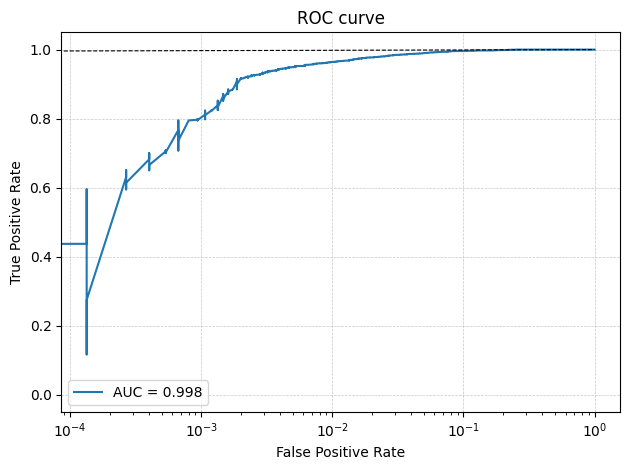

In [19]:
from building_tensorflow.utils import evaluate_binary_classifier, display_eval_metrics
train_metrics, test_metrics = evaluate_binary_classifier(inference_model, train_ds, test_ds, threshold=0.5)
display_eval_metrics(train_metrics, test_metrics)

In [20]:
from building_tensorflow.utils import get_flops_native
flops = get_flops_native(inference_model, batch_size=1)
print(f"Total FLOPs: {flops}")

Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.
Total FLOPs: 18674498


/home/nathan/Documents/tiny-chirp-microflow/building_tensorflow/.venv/lib/python3.11/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_21
Received: inputs=['Tensor(shape=(1, 47872, 1))']
  warnings.warn(msg)
2026-04-10 14:42:48.653348: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-10 14:42:48.654834: I tensorflow/core/grappler/devices.cc:66] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
2026-04-10 14:42:48.654946: I tensorflow/core/grappler/clusters/single_machine.cc:361] Starting new session
2026-04-10 14:42:48.655845: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful 

In [21]:
rep_batches = build_representative_batches(test_ds, target_len=TARGET_AUDIO_LEN_TIME, take=100)
export_keras_model_to_int8_tflite(inference_model, rep_batches, OUT_TFLITE)
print(f"Success! Wrote {OUT_TFLITE}")

clips = collect_test_clips_for_rs(
    DATASET_ROOT / "testing",
    sample_rate=SAMPLE_RATE,
    target_len=TARGET_AUDIO_LEN_TIME,
    num_per_label=2,
)
write_audio_sample_rs(
    OUT_AUDIO_RS,
    clips,
    SAMPLE_RATE,
    generator_name="building_tensorflow/leaf_time.ipynb",
)
print("Wrote", OUT_AUDIO_RS, "clips=", len(clips), "samples_per_clip=", len(clips[0][1]))


2026-04-10 14:42:49.499732: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


INFO:tensorflow:Assets written to: temp_saved_model/assets


INFO:tensorflow:Assets written to: temp_saved_model/assets


Saved artifact at 'temp_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 47872, 1), dtype=tf.float32, name='keras_tensor_21')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  139526244381296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139521877195440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139526244380768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139526244379712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139526244380240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139526244379536: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1775824970.080241  103169 tf_tfl_flatbuffer_helpers.cc:390] Ignored output_format.
W0000 00:00:1775824970.080469  103169 tf_tfl_flatbuffer_helpers.cc:393] Ignored drop_control_dependency.
2026-04-10 14:42:50.082032: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: temp_saved_model
2026-04-10 14:42:50.083077: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-10 14:42:50.083141: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: temp_saved_model
2026-04-10 14:42:50.114295: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:388] MLIR V1 optimization pass is not enabled
2026-04-10 14:42:50.121437: I tensorflow/cc/saved_model/loader.cc:234] Restoring SavedModel bundle.
2026-04-10 14:42:50.167993: I tensorflow/cc/saved_model/loader.cc:218] Running initialization op on SavedModel bundle at path: temp_saved_model
2026-04-10 14:42:50.181999: I tensorflow/cc/saved_model/loader.cc

Success! Wrote /home/nathan/Documents/tiny-chirp-microflow/models/leaf_time_tf.tflite
Found 1393 files belonging to 2 classes.


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


Wrote /home/nathan/Documents/tiny-chirp-microflow/src/audio_sample.rs clips= 4 samples_per_clip= 47872
